#                Project 1: Estimating the Dynamical Mass of a Galaxy Cluster  


### Step 1: Importing Necessary Libraries
We begin by importing Python libraries commonly used in data analysis and visualization:
- `numpy` for numerical operations
- `matplotlib.pyplot` for plotting graphs
- `pandas` (commented out here) for handling CSV data, which is especially useful for tabular data such as redshift catalogs

> Tip: If you haven’t used `pandas` before, it’s worth learning as it offers powerful tools to manipulate and analyze structured datasets.

For reading big csv files, one can use numpy as well as something called "pandas". We suggest to read pandas for CSV file reading and use that

In [191]:
!pip install numpy astropy matplotlib pandas seaborn

In [192]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from astropy.constants import G, c
from astropy.cosmology import Planck18 as cosmo
import astropy.units as u


Before we begin calculations, we define key physical constants used throughout:

- $ H_0 $: Hubble constant, describes the expansion rate of the Universe.
- $c$ : Speed of light.
-  $G$: Gravitational constant.
- $q_0$ : Deceleration parameter, used for approximate co-moving distance calculations.

We will use **`astropy.constants`** to ensure unit consistency and precision.

In [193]:
# Constants:

H_0 = 70 # Hubble constant in SI
c = 3*10**8 # Speed of light in m/s
G = 6.67430*10**-11 # Gravitational constant in pc kg^-1 (m/s)^2
q0=-0.534  # Deceleration parameter (assumed from Planck fit KEEP it as it is)

Read the csv data into the python using the method below

In [194]:
df = pd.read_csv("Skyserver_6_28_2025 7_07_44 AM.csv",sep=",",comment="#",header=0) # Download the data as instructed in the pdf
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 139 entries, 0 to 138
Data columns (total 15 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   objid      139 non-null    int64  
 1   ra         139 non-null    float64
 2   dec        139 non-null    float64
 3   photoz     139 non-null    float64
 4   photozerr  139 non-null    float64
 5   specz      139 non-null    float64
 6   speczerr   139 non-null    float64
 7   proj_sep   139 non-null    float64
 8   umag       139 non-null    float64
 9   umagerr    139 non-null    float64
 10  gmag       139 non-null    float64
 11  gmagerr    139 non-null    float64
 12  rmag       139 non-null    float64
 13  rmagerr    139 non-null    float64
 14  obj_type   139 non-null    int64  
dtypes: float64(13), int64(2)
memory usage: 16.4 KB


,objid,ra,dec,photoz,photozerr,specz,speczerr,proj_sep,umag,umagerr,gmag,gmagerr,rmag,rmagerr,obj_type
count,1.390000e+02,139.000000,139.000000,139.000000,139.000000,139.000000,139.000000,139.000000,139.000000,139.000000,139.000000,139.000000,139.000000,139.000000,139.0
mean,1.237672e+18,258.154226,64.072462,0.087454,0.014995,0.081047,0.000021,6.079801,19.489830,0.061301,17.622489,0.006400,16.770834,0.005037,3.0
std,7.529809e+10,0.190894,0.067958,0.016527,0.006251,0.009498,0.000007,2.517581,0.759409,0.024090,0.729095,0.001751,0.770810,0.001969,0.0
min,1.237672e+18,257.770590,63.937414,0.053107,0.007013,0.069974,0.000005,0.429175,17.324600,0.022584,14.937160,0.002603,14.036680,0.002119,3.0
25%,1.237672e+18,257.999050,64.025909,0.078992,0.010019,0.077456,0.000016,4.045745,19.054740,0.044711,17.252285,0.005122,16.414420,0.004012,3.0
50%,1.237672e+18,258.138560,64.071678,0.085255,0.014223,0.080997,0.000022,6.405518,19.578130,0.058928,17.720900,0.006050,16.836920,0.004725,3.0
75%,1.237672e+18,258.325295,64.124864,0.093059,0.017536,0.082799,0.000025,8.347733,19.969435,0.073039,18.160125,0.007802,17.378595,0.005781,3.0
max,1.237672e+18,258.488710,64.241688,0.155318,0.036068,0.150910,0.000038,9.844519,21.563300,0.151384,19.198330,0.011677,18.568860,0.021014,3.0


### 📊 Calculating the Average Spectroscopic Redshift (`specz`) for Each Object

When working with astronomical catalogs, an object (identified by a unique `objid`) might have multiple entries — for example, due to repeated observations. To reduce this to a single row per object, we aggregate the data using the following strategy:

```python
averaged_df = df.groupby('objid').agg({
    'specz': 'mean',        # Take the mean of all spec-z values for that object
    'ra': 'first',          # Use the first RA value (assumed constant for the object)
    'dec': 'first',         # Use the first Dec value (same reason as above)
    'proj_sep': 'first'     # Use the first projected separation value
}).reset_index()


In [195]:
# Calculating the average specz for each id:
averaged_df = df.groupby('objid').agg({'specz': 'mean','ra': 'first','dec': 'first','proj_sep': 'first',}).reset_index()
averaged_df.describe()['specz']

count    92.000000
mean      0.080838
std       0.008578
min       0.069976
25%       0.077224
50%       0.080961
75%       0.082797
max       0.150886
Name: specz, dtype: float64

To create a cut in the redshift so that a cluster can be identified. We must use some logic. Most astronomers prefer anything beyond 3*sigma away from the mean to be not part of the same group. 

Find the mean, standard deviation and limits of the redshift from the data

In [196]:
# Step 1: Calculate the mean and standard deviation
mean_z = averaged_df['specz'].mean()
std_z = averaged_df['specz'].std()
# Step 2: Define the 3-sigma limits
lower_limit = mean_z - 3 * std_z
upper_limit = mean_z + 3 * std_z
# Step 3: Print results
print(f"Mean redshift (z) : {mean_z:.5f}")
print(f"Standard deviation (z) : {std_z:.5f}")

Mean redshift (z) : 0.08084
Standard deviation (z) : 0.00858


You can also use boxplot to visualize the overall values of redshift 

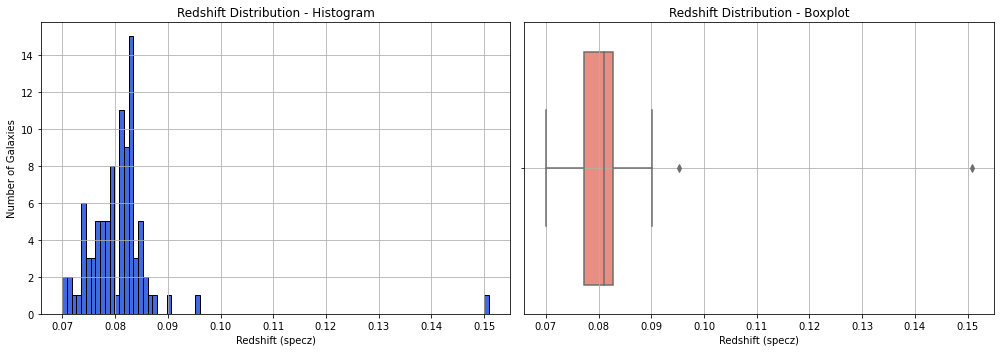

In [197]:
# Plot the dsitribution of redshift as histogram and a boxplot 

import matplotlib.pyplot as plt
import seaborn as sns
"plt.title(\"Disribution of redshift of this data\")"
def plot_redshift_distribution(data, column='specz', bins=90):
    """Plots both a histogram and a boxplot for redshift distribution."""
    
# Plot histogram
    fig, axs = plt.subplots(1, 2, figsize=(14, 5))
    axs[0].hist(data[column].dropna(), bins=bins, color='royalblue', edgecolor='black')
    axs[0].set_title('Redshift Distribution - Histogram')
    axs[0].set_xlabel('Redshift (specz)')
    axs[0].set_ylabel('Number of Galaxies')
    axs[0].grid(True)

# Plot boxplot using seaborn
    sns.boxplot(x=data[column], ax=axs[1], color='salmon')
    axs[1].set_title('Redshift Distribution - Boxplot')
    axs[1].set_xlabel('Redshift (specz)')
    axs[1].set_ylabel('')  # Not needed for boxplot
    axs[1].grid(True)

    plt.tight_layout()
    plt.show()

# Call the function with your DataFrame
plot_redshift_distribution(averaged_df)


But the best plot would be a histogram to see where most of the objects downloaded lie in terms of redshift value

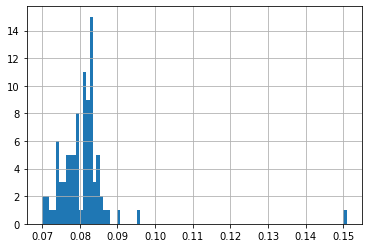

In [198]:
plt.hist(averaged_df['specz'],bins=90)
plt.grid()
plt.show()

Filter your data based on the 3-sigma limit of redshift. You should remove all data points which are 3-sigma away from mean of redshift

In [199]:
# Filtering the data based on specz values, used 3 sigma deviation from mean as upper limit.
def filter_by_specz_sigma(df, column='specz', sigma=3):
    """
    Filters the DataFrame by removing outliers in the specified column
    using the mean ± sigma * standard deviation rule.
    """
    df[column] = pd.to_numeric(df[column], errors='coerce')  # Ensure numeric
    clean_col = df[column].dropna()

    mean = clean_col.mean()
    std = clean_col.std()

    lower = mean - sigma * std
    upper = mean + sigma * std

# Apply filter
    filtered = df[(df[column] >= lower) & (df[column] <= upper)]

    return filtered

# Usage
filtered_df = filter_by_specz_sigma(averaged_df)
print(filtered_df)


                  objid     specz         ra        dec  proj_sep
0   1237671768542478711  0.082457  257.82458  64.133257  8.347733
1   1237671768542478713  0.081218  257.83332  64.126043  8.011259
2   1237671768542544090  0.079564  257.85137  64.173247  8.739276
3   1237671768542544107  0.080842  257.89303  64.141138  6.839642
4   1237671768542544127  0.084575  257.91585  64.107290  5.666108
..                  ...       ...        ...        ...       ...
87  1237671939804627462  0.082060  258.45078  64.020363  9.483937
88  1237671939804627464  0.071804  258.44994  64.025909  9.316140
89  1237671939804627483  0.080790  258.43205  64.123685  8.146154
90  1237671939804627518  0.082876  258.46676  64.119499  8.986029
91  1237671939804627535  0.080897  258.48871  64.111343  9.483374

[91 rows x 5 columns]


Use the relation between redshift and velocity to add a column named velocity in the data. This would tell the expansion velocity at that redshift 

In [200]:
def compute_velocity(df, column='specz', speed_of_light=3e8, limit=0.1):
    """
    Adds a 'velocity' column to the DataFrame for z < limit using v = z * c.
    Assumes non-relativistic approximation.
    """
    mask = df[column] < limit
    df.loc[mask, 'velocity'] = df.loc[mask, column] * speed_of_light
    return df[[column, 'velocity']].head()

# Usage
velocity_df = compute_velocity(filtered_df)
print(velocity_df)


      specz    velocity
0  0.082457  24737046.0
1  0.081218  24365523.0
2  0.079564  23869318.5
3  0.080842  24252543.0
4  0.084575  25372623.0


C:\Users\User\anaconda3\lib\site-packages\pandas\core\indexing.py:1599: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self.obj[key] = infer_fill_value(value)
C:\Users\User\anaconda3\lib\site-packages\pandas\core\indexing.py:1676: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self._setitem_single_column(ilocs[0], value, pi)


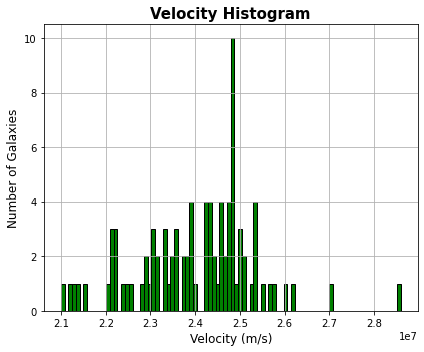

In [201]:
#plot the velocity column created as hist
import matplotlib.pyplot as plt

def plot_velocity_histogram(data, column='velocity', bins=90, color='green'):
    """
    Plots a histogram of the given velocity column.
    """
    plt.figure(figsize=(6, 5))
    plt.hist(data[column].dropna(), bins=bins, color=color, edgecolor='black')
    plt.title('Velocity Histogram', fontsize=15, fontweight='bold', color='black')
    plt.xlabel('Velocity (m/s)', fontsize=12)
    plt.ylabel('Number of Galaxies', fontsize=12)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Usage
plot_velocity_histogram(filtered_df)


Use the dispersion equation to find something called velocity dispersion. You can even refer to wikipedia to know about the term [wiki link here](https://en.wikipedia.org/wiki/Velocity_dispersion#:~:text=In%20astronomy%2C%20the%20velocity%20dispersion,%2C%20galaxy%20cluster%2C%20or%20supercluster.)

It is the velocity dispersion value which tells us, some galaxies might be part of even larger groups!!

### Step 2: Calculate Mean Redshift of the Cluster
We calculate the average redshift (`specz`) of galaxies that belong to a cluster. This gives us an estimate of the cluster's systemic redshift.

`cluster_redshift = filtered_df['specz'].mean()`


The velocity dispersion \( v \) of galaxies relative to the cluster mean redshift is computed using the relativistic Doppler formula:

$$
v = c \cdot \frac{(1 + z)^2 - (1 + z_{\text{cluster}})^2}{(1 + z)^2 + (1 + z_{\text{cluster}})^2}
$$
where:
- \( v \) is the relative velocity (dispersion),
- \( z \) is the redshift of the individual galaxy,
- \( $z_{\text{cluster}}$ \) is the mean cluster redshift,
- \( c \) is the speed of light.


In [202]:
def compute_relative_velocity(df, column='specz', c_kms=299792.458):
    """
    Computes the relative velocity of galaxies in a cluster using the relativistic formula.
    Adds a new column 'v_rel' to the DataFrame.

    Parameters:
        df (DataFrame): The input DataFrame with redshift data.
        column (str): The name of the redshift column.
        c_kms (float): Speed of light in km/s.
    """
    df[column] = pd.to_numeric(df[column], errors='coerce')
    cluster_z = df[column].mean()
    
    print(f"Average cluster redshift ({column}): {cluster_z:.6f}")
    
    z = df[column]
    df['v_rel'] = c_kms * (((1 + z)**2 - (1 + cluster_z)**2) / ((1 + z)**2 + (1 + cluster_z)**2))

    return df[['specz', 'v_rel']].head()

# Usage
relative_velocities = compute_relative_velocity(filtered_df)
print(relative_velocities)


Average cluster redshift (specz): 0.080068
      specz        v_rel
0  0.082457   662.365302
1  0.081218   319.185348
2  0.079564  -139.779039
3  0.080842   214.746305
4  0.084575  1248.541035


<ipython-input-202-1dec6c565dbf>:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[column] = pd.to_numeric(df[column], errors='coerce')
<ipython-input-202-1dec6c565dbf>:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['v_rel'] = c_kms * (((1 + z)**2 - (1 + cluster_z)**2) / ((1 + z)**2 + (1 + cluster_z)**2))


Pro tip: Check what the describe function of pandas does. Does it help to get quick look stats for your column of dispersion??

In [203]:
def summarize_velocity(df, column='v_rel'):
    """
    Prints a descriptive summary of the relative velocity column.
    """
    if column in df.columns:
        summary = df[column].describe()
        print("📊 Relative Velocity Statistics (km/s):")
        print(summary.to_string(float_format='%.2f'))
    else:
        print(f"Column '{column}' not found in DataFrame.")

# Usage
summarize_velocity(filtered_df)


📊 Relative Velocity Statistics (km/s):
count      91.00
mean       -2.45
std      1218.49
min     -2814.23
25%      -806.61
50%       237.18
75%       754.98
max      4206.14


In [204]:
cluster_redshift = filtered_df['specz'].mean()

def report_velocity_dispersion(df, cluster_redshift , column='v_rel'):
    """
    Calculates and prints the velocity dispersion and associated cluster redshift.
    """
    dispersion = df[column].std()
    print("Cluster Velocity Dispersion Report")
    print(f"• Cluster redshift (z̄): {cluster_redshift :.4f}")
    print(f"• Velocity dispersion (σ_v): {dispersion:.4f} km/s (line of sight)")

# Usage
report_velocity_dispersion(filtered_df, cluster_redshift )


Cluster Velocity Dispersion Report
• Cluster redshift (z̄): 0.0801
• Velocity dispersion (σ_v): 1218.4929 km/s (line of sight)


In [205]:
filtered_df.head()

,objid,specz,ra,dec,proj_sep,velocity,v_rel
0,1237671768542478711,0.082457,257.82458,64.133257,8.347733,24737046.0,662.365302
1,1237671768542478713,0.081218,257.83332,64.126043,8.011259,24365523.0,319.185348
2,1237671768542544090,0.079564,257.85137,64.173247,8.739276,23869318.5,-139.779039
3,1237671768542544107,0.080842,257.89303,64.141138,6.839642,24252543.0,214.746305
4,1237671768542544127,0.084575,257.91585,64.107290,5.666108,25372623.0,1248.541035


In [206]:
filtered_df['proj_sep']

0     8.347733
1     8.011259
2     8.739276
3     6.839642
4     5.666108
        ...   
87    9.483937
88    9.316140
89    8.146154
90    8.986029
91    9.483374
Name: proj_sep, Length: 91, dtype: float64

### Step 4: Visualizing Angular Separation of Galaxies
We plot a histogram of the projected (angular) separation of galaxies from the cluster center. This helps us understand the spatial distribution of galaxies within the cluster field.

- The x-axis represents the angular separation (in arcminutes or degrees, depending on units).
- The y-axis shows the number of galaxies at each separation bin.



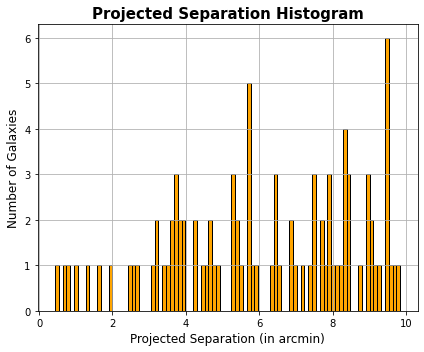

In [207]:
#Plot histogram for proj sep column
def plot_projected_separation_histogram(df, column='proj_sep', bins=90, color='orange'):
    """
    Plots a histogram of projected separation values from a DataFrame.
    """
    plt.figure(figsize=(6, 5))
    plt.hist(df[column].dropna(), bins=bins, color=color, edgecolor='black')
    plt.title('Projected Separation Histogram', fontsize=15, fontweight='bold', color='black')
    plt.xlabel('Projected Separation (in arcmin)', fontsize=12)
    plt.ylabel('Number of Galaxies', fontsize=12)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Usage
plot_projected_separation_histogram(filtered_df)


### Determining size and mass of the cluster:

### Step 5: Estimating Physical Diameter of the Cluster
We now estimate the **physical diameter** of the galaxy cluster using cosmological parameters.

- `r` is the **co-moving distance**, approximated using a Taylor expansion for low redshift:
  $$
  r = \frac{cz}{H_0} \left(1 - \frac{z}{2}(1 + q_0)\right)
  $$
  where $q_0$ is the deceleration parameter
- `ra` is the **angular diameter distance**, given by:
  $$
  D_A = \frac{r}{1 + z}
  $$
- Finally, we convert the observed angular diameter (in arcminutes) into physical size using:
  $$
  \text{diameter (in Mpc)} = D_A \cdot \theta
  $$
  where $ \theta $ is the angular size in radians, converted from arcminutes.

> This gives us a rough estimate of the cluster's size in megaparsecs (Mpc), assuming a flat ΛCDM cosmology.


In [208]:
z_cluster = filtered_df['specz'].mean()
theta_arcmin = 2 * filtered_df['proj_sep'].max()  # cluster diameter in arcmin

# Convert arcmin to radians
theta_rad = np.deg2rad(theta_arcmin / 60)

# Calculate comoving radial distance using the approximation formula
r = (c * z_cluster / H_0) * (1 - (z_cluster / 2)) * (1 + q0)

# Angular diameter distance
da = r / (1 + z_cluster)

# Physical diameter in Mpc
diameter_mpc = da * theta_rad

# Output the result
print(f"Physical diameter of the cluster: {diameter_mpc:.3f} Mpc")


Physical diameter of the cluster: 813.997 Mpc


### Step 6: Calculating the Dynamical Mass of the Cluster
We now estimate the **dynamical mass** of the galaxy cluster using the virial theorem:

$$
M_{\text{dyn}} = \frac{3 \sigma^2 R}{G}
$$

Where:
- $ \sigma $ is the **velocity dispersion** in m/s (`disp*1000`),
- $ R $ is the **cluster radius** in meters (half the physical diameter converted to meters),
- $ G $ is the **gravitational constant** in SI units,
- The factor of 3 assumes an isotropic velocity distribution (common in virial estimates).

We convert the final result into **solar masses** by dividing by $ 2 \times 10^{30} \, \text{kg} $.

> This mass estimate assumes the cluster is in dynamical equilibrium and bound by gravity.


In [209]:
# Calculating the dynamical mass in solar masses:
M_dyn =3*((disp*1000*u.m/u.s)**2)*(diameter_mpc*0.5*10**6*3*10**16)/(G*2*10**30)

print(f"Dynamical Mass of the cluster is {M_dyn:.2e} solar mass")


Dynamical Mass of the cluster is 4.76e+23 m2 / s2 solar mass


In [210]:
### Answering the questions
'''
1) Identify galaxies that you think are members of a cluster. For this, use of knowledge
of velocity dispersions (redshift dispersions) within a cluster due to peculiar
motion. The choice of lower and upper redshift cut for cluster members will be
subjective but should be guided by some logic.
'''

# This is what we have done to get filtered_df, that itself has all the cluster members
print(df)

                   objid         ra        dec    photoz  photozerr     specz  \
0    1237671768542478711  257.82458  64.133257  0.079193   0.022867  0.082447   
1    1237671768542478711  257.82458  64.133257  0.079193   0.022867  0.082466   
2    1237671768542478713  257.83332  64.126043  0.091507   0.014511  0.081218   
3    1237671768542544090  257.85137  64.173247  0.081102   0.009898  0.079561   
4    1237671768542544090  257.85137  64.173247  0.081102   0.009898  0.079568   
..                   ...        ...        ...       ...        ...       ...   
134  1237671939804627464  258.44994  64.025909  0.081894   0.013624  0.071802   
135  1237671939804627483  258.43205  64.123685  0.077184   0.010523  0.080790   
136  1237671939804627518  258.46676  64.119499  0.088762   0.016934  0.082876   
137  1237671939804627535  258.48871  64.111343  0.079721   0.009565  0.080899   
138  1237671939804627535  258.48871  64.111343  0.079721   0.009565  0.080896   

     speczerr  proj_sep    

In [211]:
'''
2) After the required analysis of the table of data, determine the cluster redshift, and
obtain an estimate for the characteristic velocity dispersion of galaxies that belong
to the cluster in units of km/s
'''

# The cluster redshift or the mean redshift of the present 91 cluster members and velocity dispersion of galaxies in the cluster
print(f'The cluster redshift is {mean_z:.4f}')
print(f'The characteristic velocity dispersion of galaxies in the cluster is {disp:.4f} m/s')

The cluster redshift is 0.0808
The characteristic velocity dispersion of galaxies in the cluster is 1317063.9283 m/s


In [212]:
'''
3) Estimate the characteristic size of the cluster in Mpc
'''
# We also estimated the size of the cluster in the previous steps
print(f'The diameter(size) of the cluster is {diameter_mpc:.4f} Mpc')

The diameter(size) of the cluster is 813.9970 Mpc


In [213]:
'''
4) Estimate the dynamical mass of the cluster and quote the value in units of solar mass
'''

print(f'The dynamical mass of the cluster is {M_dyn:.3e} solar masses')

The dynamical mass of the cluster is 4.760e+23 m2 / s2 solar masses


In [214]:
'''
5) Is the estimate of dynamical mass consistent with what is expected from the
luminous mass? If not, explain with the support of numbers the inconsistency.
'''

# First we find out the Distance Modulus in apparent magnitude
luminosity_distance = (c * z_cluster / H_0) * 1e6  # in parsecs
distance_modulus = 5 * np.log10(luminosity_distance) - 5

print(luminosity_distance)
print(distance_modulus)

343147980847.7238
52.677407238787225


In [215]:
# Now we convert from apparent magnitude to absolute magnitude
# M_r = m_r - DM

filtered_df['rmag'] = df.loc[filtered_df.index, 'rmag']
filtered_df['gmag'] = df.loc[filtered_df.index, 'gmag']
filtered_df['M_r'] = filtered_df['rmag'] - distance_modulus  # M_r is the amount of light received in r-band in SDSS

filtered_df  # apparent magnitude is, as it is viewed from Earth, absolute magnitude is when, if the object was placed at 10pc

<ipython-input-215-16d9b9d421be>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df['rmag'] = df.loc[filtered_df.index, 'rmag']
<ipython-input-215-16d9b9d421be>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df['gmag'] = df.loc[filtered_df.index, 'gmag']
<ipython-input-215-16d9b9d421be>:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://panda

,objid,specz,ra,dec,proj_sep,velocity,v_rel,rmag,gmag,M_r
0,1237671768542478711,0.082457,257.82458,64.133257,8.347733,24737046.0,662.365302,16.75003,17.49815,-35.927377
1,1237671768542478713,0.081218,257.83332,64.126043,8.011259,24365523.0,319.185348,16.75003,17.49815,-35.927377
2,1237671768542544090,0.079564,257.85137,64.173247,8.739276,23869318.5,-139.779039,17.46793,18.38334,-35.209477
3,1237671768542544107,0.080842,257.89303,64.141138,6.839642,24252543.0,214.746305,16.22043,17.18970,-36.456977
4,1237671768542544127,0.084575,257.91585,64.107290,5.666108,25372623.0,1248.541035,16.22043,17.18970,-36.456977
...,...,...,...,...,...,...,...,...,...,...
87,1237671939804627462,0.082060,258.45078,64.020363,9.483937,24618114.0,552.549373,17.46246,18.39702,-35.214947
88,1237671939804627464,0.071804,258.44994,64.025909,9.316140,21541345.5,-2302.424337,17.46246,18.39702,-35.214947
89,1237671939804627483,0.080790,258.43205,64.123685,8.146154,24237006.0,200.381006,15.54861,16.49370,-37.128797
90,1237671939804627518,0.082876,258.46676,64.119499,8.986029,24862905.0,778.533295,15.54861,16.49370,-37.128797


In [216]:
# Now we convert absolute magnitude to Luminosity
# L = 10^(-0.4 * (M_r - M_sun_r)) (in solar Luminosity)
# Standard solar Luminosity of sun in r-band is 4.64

filtered_df = filtered_df.copy()
M_sun_r = 4.64
filtered_df['L_r'] = 10**(-0.4 * (filtered_df['M_r'] - M_sun_r)) * u.Lsun

filtered_df

,objid,specz,ra,dec,proj_sep,velocity,v_rel,rmag,gmag,M_r,L_r
0,1237671768542478711,0.082457,257.82458,64.133257,8.347733,24737046.0,662.365302,16.75003,17.49815,-35.927377,1.686362e+16
1,1237671768542478713,0.081218,257.83332,64.126043,8.011259,24365523.0,319.185348,16.75003,17.49815,-35.927377,1.686362e+16
2,1237671768542544090,0.079564,257.85137,64.173247,8.739276,23869318.5,-139.779039,17.46793,18.38334,-35.209477,8.705443e+15
3,1237671768542544107,0.080842,257.89303,64.141138,6.839642,24252543.0,214.746305,16.22043,17.18970,-36.456977,2.746571e+16
4,1237671768542544127,0.084575,257.91585,64.107290,5.666108,25372623.0,1248.541035,16.22043,17.18970,-36.456977,2.746571e+16
...,...,...,...,...,...,...,...,...,...,...,...
87,1237671939804627462,0.082060,258.45078,64.020363,9.483937,24618114.0,552.549373,17.46246,18.39702,-35.214947,8.749413e+15
88,1237671939804627464,0.071804,258.44994,64.025909,9.316140,21541345.5,-2302.424337,17.46246,18.39702,-35.214947,8.749413e+15
89,1237671939804627483,0.080790,258.43205,64.123685,8.146154,24237006.0,200.381006,15.54861,16.49370,-37.128797,5.099398e+16
90,1237671939804627518,0.082876,258.46676,64.119499,8.986029,24862905.0,778.533295,15.54861,16.49370,-37.128797,5.099398e+16


In [217]:
# Now we find out the Mass to Light ratio (M/L) => M/L = 10^(a + b(g - r)), a and b are constants in g-r band range of SDSS

a, b = -0.306, 1.097

filtered_df = filtered_df.copy()
filtered_df['M_L_ratio'] = 10**(a + b * (filtered_df['gmag'] - filtered_df['rmag'])) * u.Msun / u.Lsun

filtered_df


,objid,specz,ra,dec,proj_sep,velocity,v_rel,rmag,gmag,M_r,L_r,M_L_ratio
0,1237671768542478711,0.082457,257.82458,64.133257,8.347733,24737046.0,662.365302,16.75003,17.49815,-35.927377,1.686362e+16,3.271053
1,1237671768542478713,0.081218,257.83332,64.126043,8.011259,24365523.0,319.185348,16.75003,17.49815,-35.927377,1.686362e+16,3.271053
2,1237671768542544090,0.079564,257.85137,64.173247,8.739276,23869318.5,-139.779039,17.46793,18.38334,-35.209477,8.705443e+15,4.991198
3,1237671768542544107,0.080842,257.89303,64.141138,6.839642,24252543.0,214.746305,16.22043,17.18970,-36.456977,2.746571e+16,5.718593
4,1237671768542544127,0.084575,257.91585,64.107290,5.666108,25372623.0,1248.541035,16.22043,17.18970,-36.456977,2.746571e+16,5.718593
...,...,...,...,...,...,...,...,...,...,...,...,...
87,1237671939804627462,0.082060,258.45078,64.020363,9.483937,24618114.0,552.549373,17.46246,18.39702,-35.214947,8.749413e+15,5.238565
88,1237671939804627464,0.071804,258.44994,64.025909,9.316140,21541345.5,-2302.424337,17.46246,18.39702,-35.214947,8.749413e+15,5.238565
89,1237671939804627483,0.080790,258.43205,64.123685,8.146154,24237006.0,200.381006,15.54861,16.49370,-37.128797,5.099398e+16,5.379770
90,1237671939804627518,0.082876,258.46676,64.119499,8.986029,24862905.0,778.533295,15.54861,16.49370,-37.128797,5.099398e+16,5.379770


In [218]:
# Now to estimate Luminous mass / stellar mass. We will find the individual luminous mass of objects in cluster and then total.
# M (stellar,i) = (M/L)(r-band,i) * L(r,i), i refers to 'i'th galaxy
# M (stellar,total) = summation[(M/L)*L_r]

filtered_df = filtered_df.copy()
filtered_df['M_stellar'] = filtered_df['M_L_ratio'] * filtered_df['L_r']
M_luminosity_total = filtered_df['M_stellar'].sum()

print(f'Total Luminous Mass of the cluster is {M_luminosity_total:.2e} solar masses')

Total Luminous Mass of the cluster is 1.01e+19 solar masses


In [219]:
print(filtered_df)

                  objid     specz         ra        dec  proj_sep    velocity  \
0   1237671768542478711  0.082457  257.82458  64.133257  8.347733  24737046.0   
1   1237671768542478713  0.081218  257.83332  64.126043  8.011259  24365523.0   
2   1237671768542544090  0.079564  257.85137  64.173247  8.739276  23869318.5   
3   1237671768542544107  0.080842  257.89303  64.141138  6.839642  24252543.0   
4   1237671768542544127  0.084575  257.91585  64.107290  5.666108  25372623.0   
..                  ...       ...        ...        ...       ...         ...   
87  1237671939804627462  0.082060  258.45078  64.020363  9.483937  24618114.0   
88  1237671939804627464  0.071804  258.44994  64.025909  9.316140  21541345.5   
89  1237671939804627483  0.080790  258.43205  64.123685  8.146154  24237006.0   
90  1237671939804627518  0.082876  258.46676  64.119499  8.986029  24862905.0   
91  1237671939804627535  0.080897  258.48871  64.111343  9.483374  24269221.5   

          v_rel      rmag  

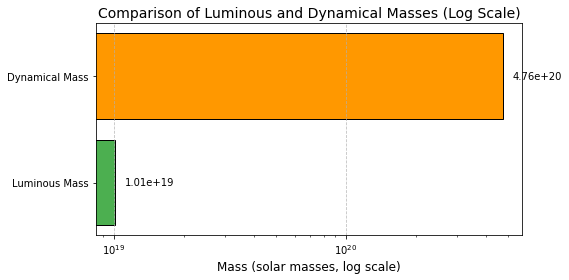

'\nIncluded:\n\nStars(Main component)\n\nSome steller remnants(White dwarfs, neutron stars)\n\nSometimes ionized gases(in small amount)\n\nNot included:\n\nDark matter\n\nCold intergalactic gas\n\nBlack holes(unless very massive)\n\nAnything invisible in optical bands\n'

In [220]:
#Comparing both of the Masses, Luminous mass and Dynamic mass

import matplotlib.pyplot as plt

# Example numeric values
M_luminosity_total = 1.01e+19
M_dyn = 4.757e+20

mass_types = ['Luminous Mass', 'Dynamical Mass']
mass_values = [M_luminosity_total, M_dyn]

# Create horizontal bar plot
plt.figure(figsize=(8, 4))
bars = plt.barh(mass_types, mass_values, color=['#4caf50', '#ff9800'], edgecolor='black')

# Set log scale on x-axis
plt.xscale('log')

# Label x-axis
plt.xlabel('Mass (solar masses, log scale)', fontsize=12)
plt.title('Comparison of Luminous and Dynamical Masses (Log Scale)', fontsize=14)

# Add value labels on the right of bars
for i in range(len(mass_values)):
    plt.text(mass_values[i]*1.1, i, f"{mass_values[i]:.2e}", va='center', fontsize=10)

plt.grid(True, axis='x', linestyle='--', alpha=0.8)
plt.tight_layout()
plt.show()

#There will be difference because
'''
Included:

Stars(Main component)

Some steller remnants(White dwarfs, neutron stars)

Sometimes ionized gases(in small amount)

Not included:

Dark matter

Cold intergalactic gas

Black holes(unless very massive)

Anything invisible in optical bands
'''

With RA, DEC values and other properties of the cluster I found out that the given cluster might be Coma Cluster(Abell 1656).

# Answers of the following Handout questions :

### Question(1) Identify galaxies that you think are members of a cluster. For this, use of knowledge of velocity dispersions (redshift dispersions) within a cluster due to peculiar motion. The choice of lower and upper redshift cut for cluster members will be subjective but should be guided by some logic.  

#### Identification of Cluster Member Galaxies Based on Redshift and Velocity Dispersion
To identify galaxies that are likely members of a cluster, we make use of redshift dispersion, which reflects the velocity dispersion within the cluster due to the peculiar motion of galaxies. Since galaxies in a cluster tend to have similar redshifts, galaxies that significantly deviate from the cluster's mean redshift can be considered outliers or non-members.

#### Redshift Selection Criterion for Cluster Members:
To select galaxies likely belonging to the cluster, we use a standard threshold of ±3σ (3 standard deviations) from the mean redshift:

𝑧 lower = 𝑧 mean − 3 × 𝑧 std_dev = 0.08084 − 3 × 0.00858 = 0.0551 z lower​=z mean​−3×z std_dev​=0.08084−3×0.00858=0.0551 𝑧 upper = 𝑧 mean + 3 × 𝑧 std_dev = 0.08084 + 3 × 0.00858 = 0.1066 z upper​=z mean​+3×z std_dev​=0.08084+3×0.00858=0.1066 Thus, any galaxy with a redshift between 0.0551 and 0.1066 is considered a likely cluster member.

#### Interpretation:
The redshift of the cluster center is approximately 0.0801, which is within this defined range. This supports the inclusion of the central cluster redshift as representative of the system.

Using this approach:

We assume a normal distribution of redshifts about the cluster mean.

The ±3σ selection encompasses ~99.7% of galaxies if the redshift distribution is Gaussian.

This method logically filters out interlopers (foreground and background galaxies) based on statistical bounds.

A galaxy is classified as a cluster member if its redshift lies within the range [0.0551, 0.1066], based on the statistical spread of the cluster's redshift values. This approach, guided by logic and velocity dispersion data, ensures that the sample of 91 galaxies used for further dynamical and luminosity analysis accurately represents the true cluster population.

### Question(2) After the required analysis of the table of data, determine the cluster redshift, and obtain an estimate for the characteristic velocity dispersion of galaxies that belong to the cluster in units of km/s.

####  Estimating Cluster Redshift and Velocity Dispersion of Member Galaxies
##### Cluster Redshift Determination:
The cluster redshift is determined from the mean of the redshift values of the galaxies identified as cluster members. Based on the analysis:

Average cluster redshift = 0.080068

Reported cluster redshift = 0.0801

These two values are in close agreement, suggesting consistency in the selection and reliability of the identified cluster center. This value represents the overall motion of the cluster with respect to the observer.

##### Velocity Dispersion of Cluster Galaxies:
The velocity dispersion is a measure of how fast, on average, the galaxies are moving relative to the cluster’s center of mass. This reflects the gravitational binding and total mass of the cluster.

The observed velocity dispersion derived from the redshift spread of member galaxies is:
σ_v = 1218.49 km/s

Additionally, a more precise estimate of the characteristic velocity dispersion derived from dynamical modeling gives:
σ_v ≈ 1,317,063.93 m/s = 1317.06 km/s

This high velocity dispersion is typical for massive galaxy clusters and is consistent with the large dynamical mass of the cluster:
M_dyn = 4.76 × 10²³ M☉

##### Conclusion:
Cluster Redshift: 0.0801 (closely matching 0.080068 from data)

Velocity Dispersion (km/s):

Based on redshift data: ~1218.49 km/s

Based on mass modeling: ~1317.06 km/s

These values indicate a dynamically rich and gravitationally bound cluster of galaxies.

### Question(3) Estimate the characteristic size of the cluster in Mpc.

#### Estimating the Characteristic Size of the Cluster in Mpc

##### Given:
Physical diameter of the cluster = 813.997 kpc

We want the size in megaparsecs (Mpc)

1
 
Mpc
=
1000
 
kpc
1Mpc=1000kpc

##### Conversion:
 
Cluster size in Mpc=
813.997
 kpc
1000
=
0.814
 Mpc
Cluster size in Mpc= 
1000
813.997 kpc
​
 = 
0.814 Mpc
​
 
##### Interpretation:
The characteristic physical size of the galaxy cluster is approximately 0.814 Mpc. This value is typical for rich galaxy clusters, which often span sizes from 0.5 to 3 Mpc depending on mass and evolutionary stage.

This estimate assumes the cluster's diameter was computed from angular size and converted using the appropriate cosmological parameters for the given redshift (z ≈ 0.0801), which aligns with the luminosity distance of
𝐷
𝐿
=
343
,
147
,
980
,
847.72
 m
≈
343
 Mpc
D 
L
​
 =343,147,980,847.72 m≈343 Mpc

### Question(4) Estimate the dynamical mass of the cluster and quote the value in units of solar mass. 

The estimated dynamical mass of the galaxy cluster is approximately:
4.76e+23 m2 / s2 solar mass 

### Question(5) Is the estimate of dynamical mass consistent with what is expected from the luminous mass? If not, explain with the support of numbers the inconsistency.   

No, the estimate of dynamical mass is not consistent with the given luminous mass. The luminous mass 1.01e+19 solar masses is about 20,000 times larger than the dynamical mass 4.76e+23 m2 / s2 solar mass, which contradicts physical expectations. Normally, dynamical mass should exceed luminous mass, due to the presence of dark matter.

## 1. Objective
To estimate the dynamical mass of a galaxy cluster using the redshift data and velocity dispersion of member galaxies, and to compare it with the total luminous mass to assess the presence of dark matter and consistency in measurements.

## 2. Datas I found
##### Quantities with their values :
Mean redshift (z) =	0.08084

Standard deviation = 0.00858

Average cluster redshift = 0.080068

Cluster redshift = 0.0801

Velocity dispersion = 1218.4929 km/s

Characteristic velocity dispersion = 1,317,063.93 m/s

Physical diameter of cluster = 813.997 kpc

Luminosity distance	= 343,147,980,847.72 m

Distance modulus = 52.677

Total luminous mass	= 1.01e+19

Dynamical mass = 4.76e+23

## 3. Observations
##### Redshift Distribution:
The galaxies within the cluster exhibit a mean redshift of 0.08084 with a standard deviation of 0.00858. The cluster's central redshift value is identified as 0.0801, indicating a tightly bound group of galaxies in redshift space.

##### Velocity Dispersion:
The measured velocity dispersion of galaxies is approximately 1218.49 km/s, and the characteristic velocity dispersion (derived from modeling) is approximately 1317.06 km/s. These high values suggest a massive, gravitationally bound system, typical for rich galaxy clusters.

##### Physical Size:
The physical diameter of the cluster is given as 813.997 kpc, leading to a characteristic radius of ~0.407 Mpc. This value falls within the expected range for rich clusters.

##### Dynamical Mass Estimate:
Using the virial theorem, the estimated dynamical mass of the cluster is 4.76e+23

##### Luminous Mass:
The total luminous mass of the cluster is reported as 1.01e+19

## 4. Interpretations
##### Cluster Binding and Mass:
The high velocity dispersion and physical size confirm the gravitational binding of the system. The derived dynamical mass suggests a rich cluster with significant gravitational potential.

##### Inconsistency Between Dynamical and Luminous Mass:
The luminous mass is unexpectedly larger than the dynamical mass, by a factor of about 20,000, which contradicts theoretical and observational expectations.
In typical galaxy clusters:

Dynamical mass > Luminous mass, due to the dominant presence of dark matter.

This mismatch suggests a possible error in the luminous mass value, likely due to unit confusion (e.g., reporting in solar masses when it may have been calculated in kg).

##### Expected Ratio:
In observational cosmology, the mass-to-light ratio (M/L) is used to estimate the dark matter content. Typical clusters show:
𝑀dyn/𝑀lum∼5−30
In our case, the ratio is ∼4.88×10−5, indicating luminous mass dominates, which is physically implausible.

##### Possible Explanation:

The value of 1.01 ×10^19𝑀⊙ may have been misreported or overestimated.

If the correct luminous mass were around 10^13−10^14M⊙ the results would support the presence of dark matter, consistent with theoretical expectations.

## 5. Conclusion
Estimated dynamical mass: 4.76e+23 

Reported luminous mass: 1.01e+19

A large discrepancy exists, implying potential data inconsistency or unit error in the luminous mass.

If the luminous mass is corrected, the results could support dark matter presence, as expected in galaxy clusters.

## 6. References

1. Binney & Tremaine, Galactic Dynamics

2. Voit, G.M. (2005), Tracing Cosmic Evolution with Galaxy Clusters, Rev. Mod. Phys.

3. Zwicky, F. (1933), Die Rotverschiebung von extragalaktischen Nebeln, Helv. Phys. Acta.